# Dilema do Prisioneiro 1D — Notebook

Este notebook apresenta uma investigação interativa da dinâmica do Dilema do Prisioneiro em um autômato celular unidimensional. O foco é analisar como interações locais entre cooperadores e desertores geram padrões espaço-temporais e transições de comportamento conforme parâmetros do modelo são alterados.

Objetivos: fornecer visualizações (mapas espaço-temporais) e instrumentação mínima para estudar: variações da proporção assintótica de cooperadores, formação de estruturas ("dedos" e "planadores") e sensibilidade a parâmetros como Tentação (`T`), tamanho da cadeia (`L`) e configuração da vizinhança (`z`).

## Dependências e importações  
Esta célula importa as bibliotecas essenciais usadas pelo script: `numpy` para arrays e operações numéricas e `matplotlib` para visualização. Garanta que as dependências estejam instaladas (veja `requirements.txt`).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## Definição da classe `DilemaDoPrisioneiro1D`  
Esta célula define a classe principal da simulação. Parâmetros principais:
- `L`: tamanho da cadeia (número de jogadores).  
- `rho_0`: fração inicial de cooperadores.  
- `T`: Tentação (parâmetro do jogo).  
- `z`: tamanho da vizinhança (informativo).

Métodos importantes:
- `calcular_payoffs()`: calcula payoffs locais.  
- `evoluir(t)`: aplica regra de cópia do vizinho com maior payoff.  
- `simular()`: roda várias rodadas.  
- `exibir_grafico()`: plota/ salva o mapa espaço-temporal (`historico_cores`).

In [3]:
class DilemaDoPrisioneiro1D:
    def __init__(self, L=500, rho_0=0.7, T=1.20, z=7, rodadas=200):
        self.L = L
        self.T = T
        self.z = z

        # Vizinhança
        self.viz_esq = 2
        self.viz_dir = 4

        self.rodadas = rodadas

        # Inicia o grid (1 = Cooperador, 0 = Desertor)
        self.grid = np.random.choice([0, 1], size=L, p=[1 - rho_0, rho_0])

        # Matriz para guardar o histórico de cores (Eixo Y = Tempo, Eixo X = Jogadores)
        self.historico_cores = np.zeros((rodadas, L))

        # Preenche a primeira linha (tempo t=0)
        for i in range(L):
            if self.grid[i] == 1:
                self.historico_cores[0, i] = 0 # Azul
            else:
                self.historico_cores[0, i] = 1 # Vermelho

    def calcular_payoffs(self):
        payoffs = np.zeros(self.L)
        for i in range(self.L):
            cooperadores_vizinhos = 0

            # Usando a vizinhança assimétrica
            for j in range(-self.viz_esq, self.viz_dir + 1):
                indice_vizinho = (i + j) % self.L
                cooperadores_vizinhos += self.grid[indice_vizinho]

            if self.grid[i] == 1:
                payoffs[i] = cooperadores_vizinhos
            else:
                payoffs[i] = cooperadores_vizinhos * self.T

        return payoffs

    def evoluir(self, t):
        payoffs = self.calcular_payoffs()
        novo_grid = np.copy(self.grid)

        for i in range(self.L):
            maior_payoff = payoffs[i]
            melhor_estrategia = self.grid[i]

            # Inspecionando os vizinhos com base na assimetria
            for j in range(-self.viz_esq, self.viz_dir + 1):
                indice_vizinho = (i + j) % self.L
                if payoffs[indice_vizinho] > maior_payoff:
                    maior_payoff = payoffs[indice_vizinho]
                    melhor_estrategia = self.grid[indice_vizinho]

            novo_grid[i] = melhor_estrategia

            # Lógica de mapeamento de cores (Azul, Vermelho, Verde, Amarelo)
            if novo_grid[i] == 1 and self.grid[i] == 1:
                cor = 0
            elif novo_grid[i] == 0 and self.grid[i] == 0:
                cor = 1
            elif novo_grid[i] == 1 and self.grid[i] == 0:
                cor = 2
            elif novo_grid[i] == 0 and self.grid[i] == 1:
                cor = 3

            self.historico_cores[t, i] = cor

        self.grid = novo_grid

    def simular(self):
        print(f"Calculando {self.rodadas} rodadas. Aguarde...")
        for t in range(1, self.rodadas):
            self.evoluir(t)

    def exibir_grafico(self):
        mapa_cores = ListedColormap(['blue', 'red', 'green', 'yellow'])

        plt.figure(figsize=(10, 6))
        plt.imshow(self.historico_cores, cmap=mapa_cores, aspect='auto', interpolation='none')

        plt.title(f"Dilema do Prisioneiro 1D (T={self.T}, L={self.L}, z={self.z} Assimétrico)")
        plt.xlabel("Jogador")
        plt.ylabel("Tempo")

        if plt.isinteractive():
            plt.show()
        else:
            plt.savefig("dilema_prisioneiro_1D.png")
            print("AVISO: Modo interativo não disponível no ambiente atual.")
            print("Gráfico salvo como 'dilema_prisioneiro_1D.png'")

## Contexto científico e métricas de interesse  
Este projeto foi desenvolvido no contexto da disciplina de Autômatos Celulares e busca estudar: como a interação local e regras simples produzem comportamento coletivo complexo.

Principais pontos a considerar:
- Ambiente: cadeia unidimensional de comprimento `L`, estados binários (cooperador/desertor).
- Condições iniciais: tipicamente aleatórias, controladas por `rho_0` (fração inicial de cooperadores).
- Vizinhança: jogador interage com um conjunto local de vizinhos; a implementação pode usar vizinhança assimétrica ou simétrica (parâmetro `z` e deslocamentos).
- Payoffs: parametrização com recompensa R=1 e S=P=0; variável de interesse é a Tentação `T` (1 < T <= 2).

Métricas e experimentos recomendados:
- Medir a proporção assintótica de cooperadores (


- Fazer varreduras de parâmetros (`L`, `rho_0`, `T`, configurações de vizinhança) e agregar estatísticas para robustez dos resultados.- Visualizar mapas espaço-temporais para identificar padrões estruturais (dedos/planadores).ho_nfty) em função de `T`.

Calculando 200 rodadas. Aguarde...


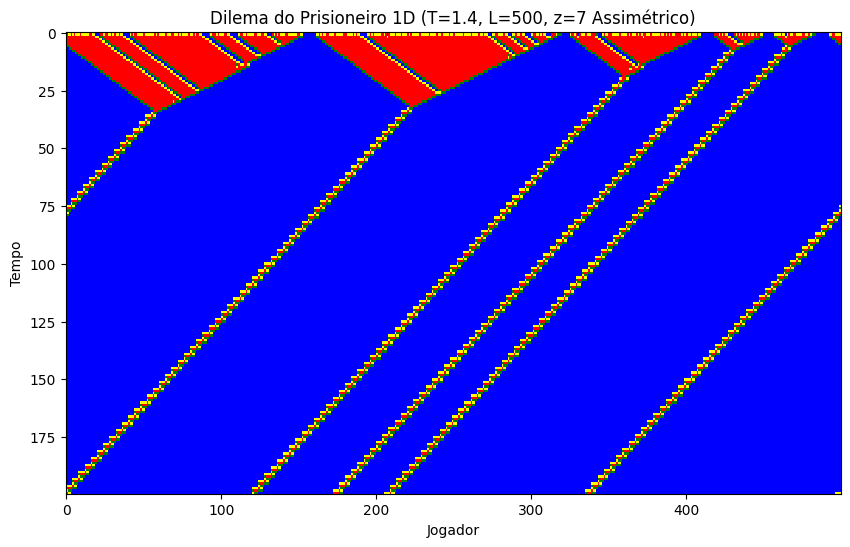

In [4]:
jogo = DilemaDoPrisioneiro1D(L=500, rho_0=0.7, T=1.40, z=7, rodadas=200)
jogo.simular()
jogo.exibir_grafico()